In [10]:
# Memory safety: cap this kernel to the RAM free right now so an out-of-memory
# operation fails with a clean MemoryError instead of crashing VS Code /
# thrashing swap. For very large parquet loads, read_parquet_float32() from this
# module keeps peak memory bounded.
import os, sys
sys.path.insert(0, os.path.abspath("../../../Generic-Parallel-Compute-Helper/")) ; from memory_compute import *
install_memory_guard()


[memory_guard] hard cap 13.3G virtual on this kernel (total RAM 14.8G, 8.8G free now). Runaway allocations fail cleanly; bounded streaming keeps normal work well under this.


14298148864

# Final Model Results: Actual vs Predicted

Loads `variables.ACTUAL_VS_PREDICTED_TEST_SET` (written by `5_Model/4_evaluate_model.ipynb`) and visualises
how the final ensemble's test-set predictions compare against actual prices: per-horizon error/skill,
time-series overlays, actual-vs-predicted scatter, and residual distributions.

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath("../../")); from EPF import variables

combined_df = pd.read_parquet(variables.ACTUAL_VS_PREDICTED_TEST_SET)
combined_df.index = pd.to_datetime(combined_df.index)
horizon_list = sorted(int(c.split("_h")[1]) for c in combined_df.columns if c.startswith("actual_h"))

print(f"Loaded {len(combined_df):,} test rows across {len(horizon_list)} horizons "
      f"({combined_df.index.min()} to {combined_df.index.max()})")

Loaded 105,114 test rows across 1 horizons (2025-01-01 00:05:00 to 2025-12-31 23:30:00)


## Per-horizon accuracy

In [12]:
def _rmse(yt, yp):
    return float(np.sqrt(mean_squared_error(yt, yp)))

step_records = []
for h in horizon_list:
    yt = combined_df[f"actual_h{h}"].values
    yp = combined_df[f"predicted_h{h}"].values
    valid = ~np.isnan(yt) & ~np.isnan(yp)
    yt, yp = yt[valid], yp[valid]
    step_records.append({
        "h": h,
        "lead_h": round(h * variables.HORIZON_GRANULARITY_IN_MINUTES / 60, 1),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": _rmse(yt, yp),
        "r2": float(r2_score(yt, yp)),
        "mbe": float(np.mean(yp - yt)),
    })

steps_df = pd.DataFrame(step_records)
steps_df.head(10)

,h,lead_h,mae,rmse,r2,mbe
0,1,0.5,35.706066,283.955556,0.462501,11.519575


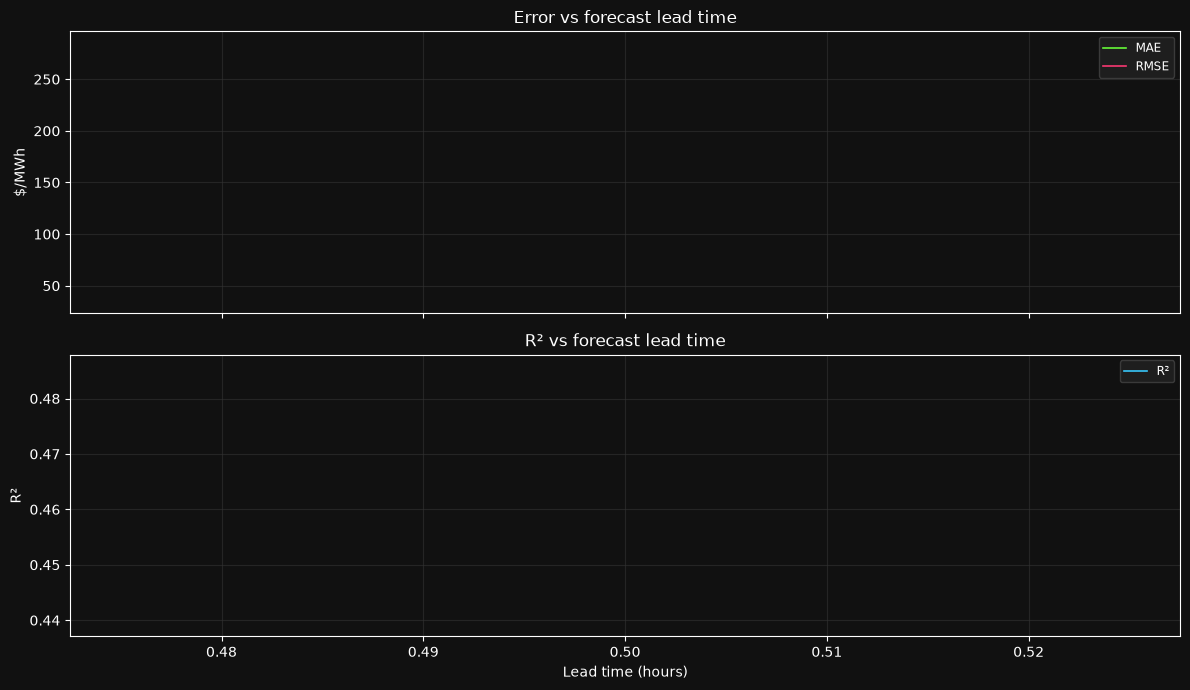

In [13]:
plt.style.use("dark_background")
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.patch.set_facecolor("#111111")

for ax in axes:
    ax.set_facecolor("#111111")
    ax.grid(True, color="#333333", alpha=0.6)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

axes[0].plot(steps_df["lead_h"], steps_df["mae"], color="#65f838", label="MAE", linewidth=1.2)
axes[0].plot(steps_df["lead_h"], steps_df["rmse"], color="#f83872", label="RMSE", linewidth=1.2)
axes[0].set_ylabel("$/MWh")
axes[0].set_title("Error vs forecast lead time")

axes[1].plot(steps_df["lead_h"], steps_df["r2"], color="#38c6f8", label="R\u00b2", linewidth=1.2)
axes[1].set_ylabel("R\u00b2")
axes[1].set_xlabel("Lead time (hours)")
axes[1].set_title("R\u00b2 vs forecast lead time")

for ax in axes:
    ax.legend(fontsize="small", facecolor="#222222", edgecolor="#444444", labelcolor="white", loc="upper right")

plt.tight_layout()
plt.show()

## Actual vs predicted over time (selected horizons)

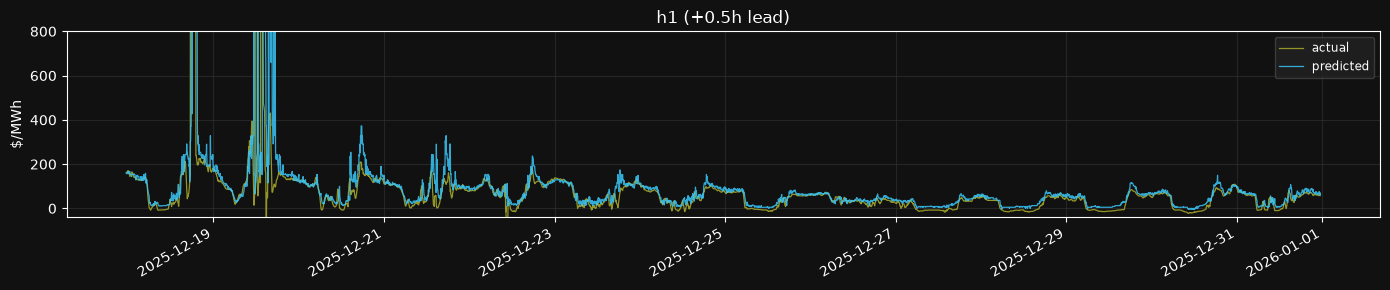

In [14]:
SELECTED_HORIZONS = [h for h in (1, 12, 48, 96) if h in horizon_list]
RECENT_DAYS = 14
window_df = combined_df.loc[combined_df.index >= combined_df.index.max() - pd.Timedelta(days=RECENT_DAYS)]

fig, axes = plt.subplots(len(SELECTED_HORIZONS), 1, figsize=(14, 3 * len(SELECTED_HORIZONS)), sharex=True)
fig.patch.set_facecolor("#111111")
if len(SELECTED_HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, SELECTED_HORIZONS):
    ax.set_facecolor("#111111")
    ax.grid(True, color="#333333", alpha=0.6)
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

    lead_h = round(h * variables.HORIZON_GRANULARITY_IN_MINUTES / 60, 1)
    ax.plot(window_df.index, window_df[f"actual_h{h}"], color="#949628", label="actual", linewidth=0.9)
    ax.plot(window_df.index, window_df[f"predicted_h{h}"], color="#38c6f8", label="predicted", linewidth=0.9, alpha=0.85)
    ax.set_ylabel("$/MWh")
    ax.set_ylim(top=800,bottom=-40)
    ax.set_title(f"h{h} (+{lead_h}h lead)")
    ax.legend(fontsize="small", facecolor="#222222", edgecolor="#444444", labelcolor="white", loc="upper right")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right", color="white")
plt.tight_layout()
plt.show()

## Residual distribution

In [17]:
# Free this kernel's memory so the next notebook has RAM to work with
# (clears data variables + returns freed heap to the OS).
release_memory()


[release_memory] cleared 17 variable(s); kernel rss 0.27G, 8.9G RAM free now
